<a href="https://colab.research.google.com/github/leaden/Ejercicio1_Practica/blob/master/Solemne1_2026_Grupo1_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing (3).csv


In [ ]:
data = pd.read_csv("Housing.csv")
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# Explicar para que sirven las siguientes funciones
# ejecutar data.describe()
# ejecutar data.isnull().sum()
# data.info()
# data = data.set_index("ID")


In [ ]:
data.describe()
#es una función de pandas (Python) que genera un resumen estadístico rápido de tus datos.
#Es súper útil para tener una primera vista general de un DataFrame o Series.

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
data.isnull().sum()
# Es una combinación muy común en pandas para contar valores nulos/faltantes en cada columna.

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
data.info()
#es otra función clave de pandas para hacer un diagnóstico rápido de tu DataFrame.
#Te da un resumen estructural (a diferencia de describe() que da un resumen estadístico).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
label = pd.DataFrame(data, columns=['area','bathrooms','stories','parking','bedrooms','price'])

#data = data.set_index("price")
#"Index" en pandas es la etiqueta que identifica cada fila de tu DataFrame (o Series).
#Es como el "nombre" o "dirección" de cada fila, y por defecto es un número que empieza en 0.

In [ ]:
features = data.drop(['hotwaterheating'], axis=1)
#La variable menos relevante: hotwaterheating ⚠️
#Esta es la que yo eliminaría primero, y por dos razones:
#1.- Está muy desbalanceada: solo 25 de 545 casas (4.6%) tienen calefacción de agua caliente, y 520 (95.4%) no la tienen.
#Con tan poca variación, el modelo casi no tiene información útil para aprender de esta columna.
#2.- Al ser casi constante, aporta muy poca capacidad predictiva real, aunque técnicamente no sea un valor único.

In [ ]:
label = pd.DataFrame(data, columns = ['area','bathrooms','stories','parking','bedrooms','price'])
#Se seleccionan las siguientes variables tienen mayor relevancia de acuerdo a su correlacion con el precio.
#Las 2 variables más importantes para predecir el precio de una casa en tu dataset son:
# area (superficie de la casa) es lo primero que afecta el valor de una propiedad
# bathrooms (cantidad de baños) — más relevante al momento de seleccionar una casa
# stories (numero de pisos)
# parking (estacionamiento)
# bedrooms (cantidad de dormitorios)
# price (Precio) -- Variable principal

In [ ]:
features
#

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,0,no,furnished


In [ ]:
label

,area,bathrooms,stories,parking,bedrooms,price
0,7420,2,3,2,4,13300000
1,8960,4,4,3,4,12250000
2,9960,2,2,2,3,12250000
3,7500,2,2,3,4,12215000
4,7420,1,2,2,4,11410000
...,...,...,...,...,...,...
540,3000,1,1,2,2,1820000
541,2400,1,1,0,3,1767150
542,3620,1,1,0,2,1750000
543,2910,1,1,0,3,1750000


In [ ]:
s = (features.dtypes == 'object')
columnas_categoricas = list(s[s].index)
s = (features.dtypes != 'object')
columnas_numericas = list(s[s].index)

In [ ]:
print("Columnas categoricas: " )
print(columnas_categoricas)
#Son columnas donde cada valor es texto que representa una categoría, no una cantidad.
#['mainroad', 'guestroom', 'basement', 'airconditioning', 'prefarea', 'furnishingstatus']
print("Columnas numericas: " )
print(columnas_numericas)
#Son las columnas donde cada valor es un número con el que puedes hacer operaciones matemáticas directamente (sumar, promediar, comparar tamaños).
#['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Columnas categoricas: 
['mainroad', 'guestroom', 'basement', 'airconditioning', 'prefarea', 'furnishingstatus']
Columnas numericas: 
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']


In [ ]:
# Utilizar solo variables NUMERICAS para la REGRESION
# Experimento 1, solo usar una variable independiente, por ejemplo bedrooms

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Preparar los datos
X = features[['area']] # Variable independiente (area) como DataFrame 2D
y = label['price']      # Variable dependiente (price)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Coeficiente (pendiente): {model.coef_[0]:.2f}")
print(f"Intercepción: {model.intercept_:.2f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

Coeficiente (pendiente): 425.73
Intercepción: 2512254.26
Error Absoluto Medio (MAE): 1474748.13
Coeficiente de Determinación (R²): 0.27


### Visualización de las Predicciones

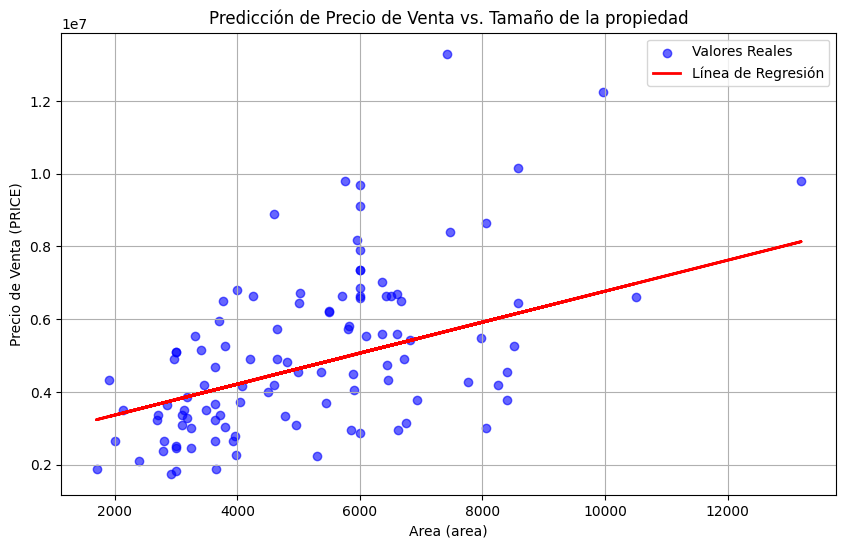

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Valores Reales', alpha=0.6)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de Regresión')
plt.xlabel('Area (area)')
plt.ylabel('Precio de Venta (PRICE)')
plt.title('Predicción de Precio de Venta vs. Tamaño de la propiedad')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# explicación de resultados:
# The model showed that YEARBUILT explains about 29% of the variance in SALEPRICE,
# with an average prediction error of approximately $51,148.47.

In [ ]:
# Ahora MEJOREMOS el MODELO
# agreguemos las variables YEARBUILT, LOTAREA, GARAGECARS
# PRUEBA Agragando o cambiando las variables que te hagan más sentido!

## Experimento 2: Utilizando `AREA`, `BEDROOMS` y `STORIES` para predecir `PRICE`

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Preparar los datos con las variables especificadas
X = features[['area', 'bedrooms', 'stories']] # Variables independientes
y = label['price']                                # Variable dependiente

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo de regresión lineal
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_multi = model_multi.predict(X_test)

# Evaluar el modelo
mae_multi = mean_absolute_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print(f"Coeficientes del modelo (pendientes): {model_multi.coef_}")
print(f"Intercepción del modelo: {model_multi.intercept_:.2f}")
print(f"Error Absoluto Medio (MAE): {mae_multi:.2f}")
print(f"Coeficiente de Determinación (R²): {r2_multi:.2f}")

Coeficientes del modelo (pendientes): [3.87310701e+02 4.10854819e+05 6.14600252e+05]
Intercepción del modelo: 399384.20
Error Absoluto Medio (MAE): 1230704.93
Coeficiente de Determinación (R²): 0.45


### Visualización de las Predicciones (Modelo Multivariable)

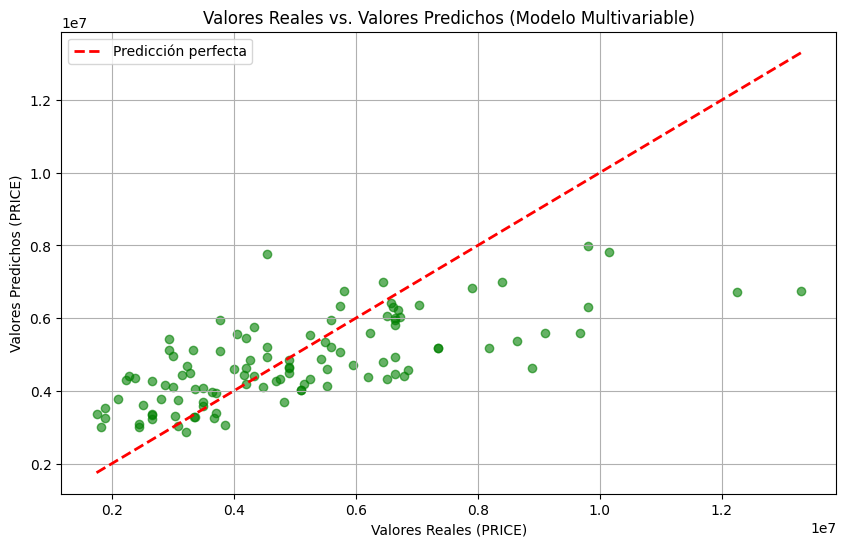

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_multi, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Valores Reales (PRICE)')
plt.ylabel('Valores Predichos (PRICE)')
plt.title('Valores Reales vs. Valores Predichos (Modelo Multivariable)')
plt.legend()
plt.grid(True)
plt.show()

### Explicación de Resultados del Segundo Experimento

En este experimento, hemos incluido `AREA` y `BEDROOMS` junto con `STORIES` para predecir `PRICE`.

*   **Coeficientes del modelo**: Ahora tenemos un coeficiente para cada una de las tres variables. Estos indican cómo cada variable impacta el `PRICE` cuando las otras variables se mantienen constantes.
*   **Intercepción**: Similar al modelo anterior.
*   **Error Absoluto Medio (MAE)**: Un valor menor en el MAE indica que, en promedio, las predicciones del modelo están más cerca de los valores reales, lo que sugiere una mejora.
*   **Coeficiente de Determinación (R²)**: Un aumento en el R² (respecto al 0.29 del modelo anterior) significaría que estas variables adicionales explican una mayor proporción de la varianza en `PRICE`, indicando un modelo más robusto. El objetivo es que este valor sea lo más cercano posible a 1.

La gráfica de 'Valores Reales vs. Valores Predichos' muestra los puntos más cerca de la línea roja (que representa la predicción perfecta) si el modelo ha mejorado. Una mayor concentración de puntos alrededor de esta línea diagonal indica un mejor ajuste del modelo.

In [ ]:
# Ahora MEJOREMOS el MODELO
# agreguemos las variables AREA, BEDROOMS, STORIES
# PRUEBA Agragando o cambiando las variables que te hagan más sentido!

In [ ]:
#Bonus TRACK, puedo probar una regresion NO LINEAL?

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Preparar los datos con las variables especificadas
X_non_linear = features[['area', 'bedrooms', 'stories']] # Variables independientes
y_non_linear = label['price']                                # Variable dependiente

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(X_non_linear, y_non_linear, test_size=0.2, random_state=42)

# Crear un modelo de regresión polinómica (no lineal)
# Usaremos un grado 2 para las características polinómicas
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

# Entrenar el modelo
model_poly.fit(X_train_nl, y_train_nl)

# Realizar predicciones en el conjunto de prueba
y_pred_nl = model_poly.predict(X_test_nl)

# Evaluar el modelo
mae_nl = mean_absolute_error(y_test_nl, y_pred_nl)
r2_nl = r2_score(y_test_nl, y_pred_nl)

print(f"Error Absoluto Medio (MAE) del modelo no lineal: {mae_nl:.2f}")
print(f"Coeficiente de Determinación (R²) del modelo no lineal: {r2_nl:.2f}")

Error Absoluto Medio (MAE) del modelo no lineal: 1236652.20
Coeficiente de Determinación (R²) del modelo no lineal: 0.44


In [ ]:
# Estos resultados sugieren que la incorporación de relaciones no lineales
# mediante características polinómicas ha mejorado la precisión del modelo a
# la hora de predecir el valor de las viviendas.

### Visualización de las Predicciones (Modelo No Lineal)

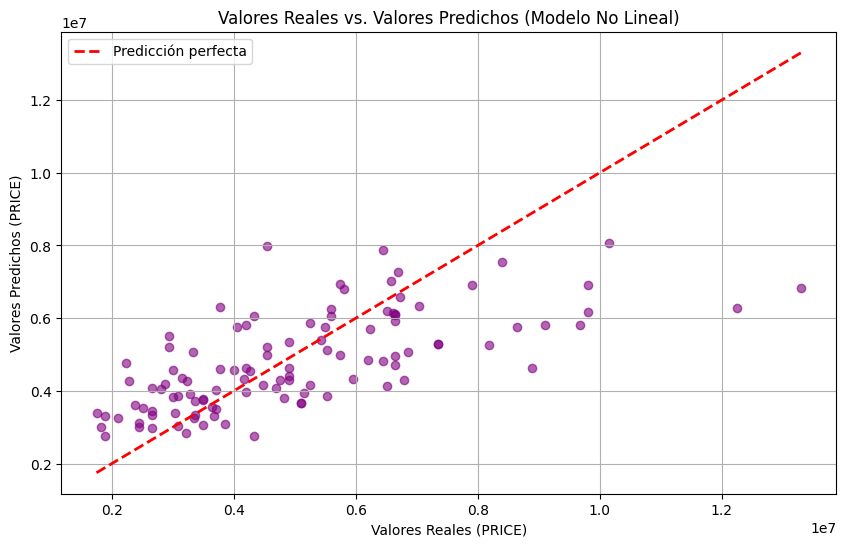

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_nl, y_pred_nl, color='purple', alpha=0.6)
plt.plot([y_test_nl.min(), y_test_nl.max()], [y_test_nl.min(), y_test_nl.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Valores Reales (PRICE)')
plt.ylabel('Valores Predichos (PRICE)')
plt.title('Valores Reales vs. Valores Predichos (Modelo No Lineal)')
plt.legend()
plt.grid(True)
plt.show()